# Fase 3: pipeline ergonomico lateral con YOLO Pose

Esta libreta extiende el trabajo frontal con una vista de perfil.

Objetivo:
- usar `YOLO Pose` como modelo de keypoints para imagenes laterales
- validar el dataset lateral principal con una muestra pequena
- transformar keypoints laterales en variables ergonomicas interpretables
- dejar preparada una corrida larga reanudable para cuando queramos procesar todo el dataset

Alcance de esta iteracion:
- dataset `sitting_posture_4keypoint`
- reglas laterales iniciales para cabeza adelantada, inclinacion de cuello/tronco y codo
- benchmark grande y calibracion quedan para la siguiente revision con resultados ya ejecutados

In [12]:
from __future__ import annotations

import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists():
            return candidate
    return current


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.max_columns = 80
pd.options.display.float_format = "{:,.3f}".format

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"SRC_DIR: {SRC_DIR}")

PROJECT_ROOT: /home/veleiro/OneDrive/Clase/3º de IA/2º Cuatri/Proyecto Integrador I/Proyecto/Proyecto-Integrador-I
SRC_DIR: /home/veleiro/OneDrive/Clase/3º de IA/2º Cuatri/Proyecto Integrador I/Proyecto/Proyecto-Integrador-I/src


In [13]:
from ergonomics import (
    ERGONOMICS_RESULTS_DIR,
    YOLO_POSE_WEIGHTS_PATH,
    YoloPoseConfig,
    analyze_lateral_pose_dataframe,
    build_group_status_summary,
    build_metric_summary_by_group,
    build_status_summary,
    draw_pose_overlay,
    plot_metric_by_group,
    plot_status_by_group,
    plot_status_distribution,
    run_incremental_lateral_yolo_pipeline,
    run_yolo_pose_batch,
    select_balanced_sample,
    select_execution_records,
    summarize_dataset_groups,
)

## 1. Configuracion lateral

La vista lateral se trata como una ampliacion del sistema frontal.
El benchmark lateral favorece YOLO Pose, asi que esta libreta usa YOLO para landmarks.

Para pruebas pequenas, ajusta `SAMPLE_PER_GROUP`.
Para corrida larga, usa la seccion 6 y deja `LATERAL_MAX_IMAGES = None`.

In [14]:
DATASET_KEY = "sitting_posture_4keypoint"
SPLITS = ("train", "valid", "test")
SAMPLE_PER_GROUP = 4
SEED = 7

VISIBILITY_THRESHOLD = 0.3
YOLO_DEVICE = os.getenv("YOLO_DEVICE", "auto")

display(
    Markdown(
        f"""
**Configuracion activa**

- Dataset lateral: `{DATASET_KEY}`
- Modelo de keypoints: `YOLO Pose`
- Pesos: `{YOLO_POSE_WEIGHTS_PATH}`
- Dispositivo YOLO: `{YOLO_DEVICE}`
- Threshold de confianza: `{VISIBILITY_THRESHOLD}`
- Muestra por grupo: `{SAMPLE_PER_GROUP}`
"""
    )
)


**Configuracion activa**

- Dataset lateral: `sitting_posture_4keypoint`
- Modelo de keypoints: `YOLO Pose`
- Pesos: `/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatri/Proyecto Integrador I/Proyecto/Proyecto-Integrador-I/models/yolo/yolov8s-pose.pt`
- Dispositivo YOLO: `auto`
- Threshold de confianza: `0.3`
- Muestra por grupo: `4`


## 2. Dataset lateral

Este dataset es el principal para perfil porque la mayoria de imagenes son de escritorio en vista lateral.
La lectura COCO conserva las clases `Good` y `Bad`, que usaremos para contrastar resultados.

In [15]:
group_summary_df = summarize_dataset_groups(DATASET_KEY)
display(group_summary_df)

sample_df = select_balanced_sample(
    DATASET_KEY,
    per_group=SAMPLE_PER_GROUP,
    splits=SPLITS,
    seed=SEED,
)

display(sample_df)
print(f"Total de imagenes en la muestra lateral: {len(sample_df)}")

,split,group,image_count
0,train,Bad,366
1,train,Good,207
2,valid,Bad,37
3,valid,Good,18
4,test,Bad,17
5,test,Good,10


,image_path,group,split
0,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,Bad,train
1,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,Bad,train
2,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,Bad,train
3,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,Bad,train
4,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,Good,test
5,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,Good,train
6,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,Good,train
7,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...,Good,train


Total de imagenes en la muestra lateral: 8


## 3. Inferencia YOLO sobre muestra pequena

Esta celda hace una prueba reducida. Sirve para revisar rapidamente:
- si YOLO detecta persona
- cuantos keypoints utiles aparecen
- si el lado corporal visible queda bien elegido por las reglas laterales

In [16]:
yolo_config = YoloPoseConfig(
    weights_path=YOLO_POSE_WEIGHTS_PATH,
    device=YOLO_DEVICE,
    min_confidence=VISIBILITY_THRESHOLD,
)

pose_df = run_yolo_pose_batch(sample_df, config=yolo_config)

display(
    pose_df[
        [
            "image_name",
            "group",
            "split",
            "pose_backend",
            "pose_detected",
            "visible_landmarks_count",
            "pose_landmarks_count",
        ]
    ]
)

,image_name,group,split,pose_backend,pose_detected,visible_landmarks_count,pose_landmarks_count
0,bad_posture_20241013_225750_png.rf.1917a0638ba...,Bad,train,torch_cuda:0,True,7,17
1,bad_posture_20241021_143948_png.rf.8a78740d641...,Bad,train,torch_cuda:0,True,9,17
2,bad_posture_20241021_143948_png.rf.d48d2917df4...,Bad,train,torch_cuda:0,True,9,17
3,image_20241007_214540_jpg.rf.8d780431f2350ebc2...,Bad,train,torch_cuda:0,True,9,17
4,image_20241008_200613_jpg.rf.531a35da0b7cda2b9...,Good,test,torch_cuda:0,True,9,17
5,good_posture_20241013_222738_png.rf.802542d1e3...,Good,train,torch_cuda:0,True,9,17
6,good_posture_20241021_142755_png.rf.44e116974e...,Good,train,torch_cuda:0,True,9,17
7,good_posture_20241021_180318_png.rf.133186cd10...,Good,train,torch_cuda:0,True,9,17


## 4. Variables y reglas ergonomicas laterales

En perfil ya podemos medir mejor lo que el frontal no resolvia bien:
- cabeza adelantada respecto al hombro
- inclinacion cuello-hombro
- inclinacion tronco-cadera
- angulo de codo si aparece la muneca

Los umbrales son una primera version interpretable. Quedan pensados para recalibrarse tras la corrida grande y auditoria visual.

In [17]:
analysis_df = analyze_lateral_pose_dataframe(
    pose_df,
    visibility_threshold=VISIBILITY_THRESHOLD,
)

demo_results_df = pose_df[
    [
        "image_path",
        "visible_landmarks_count",
        "pose_landmarks_count",
        "pose_detected",
    ]
].merge(
    analysis_df,
    on=["image_path", "pose_detected"],
    how="inner",
)

display(
    demo_results_df[
        [
            "image_name",
            "group",
            "overall_status",
            "lateral_side",
            "lateral_chain_ready",
            "head_forward_offset_ratio",
            "neck_forward_tilt_deg",
            "trunk_forward_tilt_deg",
            "shoulder_hip_offset_ratio",
            "lateral_elbow_angle_deg",
            "feedback",
        ]
    ]
)

,image_name,group,overall_status,lateral_side,lateral_chain_ready,head_forward_offset_ratio,neck_forward_tilt_deg,trunk_forward_tilt_deg,shoulder_hip_offset_ratio,lateral_elbow_angle_deg,feedback
0,bad_posture_20241013_225750_png.rf.1917a0638ba...,Bad,risk,right,True,0.624,78.009,16.062,0.277,81.836,Acerca la cabeza al eje del tronco y evita ade...
1,bad_posture_20241021_143948_png.rf.8a78740d641...,Bad,risk,right,True,0.562,68.079,9.393,0.163,112.856,Acerca la cabeza al eje del tronco y evita ade...
2,bad_posture_20241021_143948_png.rf.d48d2917df4...,Bad,risk,right,True,0.587,67.815,17.167,0.295,117.409,Acerca la cabeza al eje del tronco y evita ade...
3,image_20241007_214540_jpg.rf.8d780431f2350ebc2...,Bad,risk,right,True,0.568,85.272,13.322,0.230,111.145,Acerca la cabeza al eje del tronco y evita ade...
4,image_20241008_200613_jpg.rf.531a35da0b7cda2b9...,Good,risk,right,True,0.478,60.509,4.237,0.074,111.111,Acerca la cabeza al eje del tronco y evita ade...
5,good_posture_20241013_222738_png.rf.802542d1e3...,Good,risk,right,True,0.501,62.683,6.549,0.114,92.707,Acerca la cabeza al eje del tronco y evita ade...
6,good_posture_20241021_142755_png.rf.44e116974e...,Good,risk,left,True,0.405,57.686,4.804,0.084,127.666,Acerca la cabeza al eje del tronco y evita ade...
7,good_posture_20241021_180318_png.rf.133186cd10...,Good,risk,left,True,0.362,51.859,4.575,0.080,144.059,Acerca la cabeza al eje del tronco y evita ade...


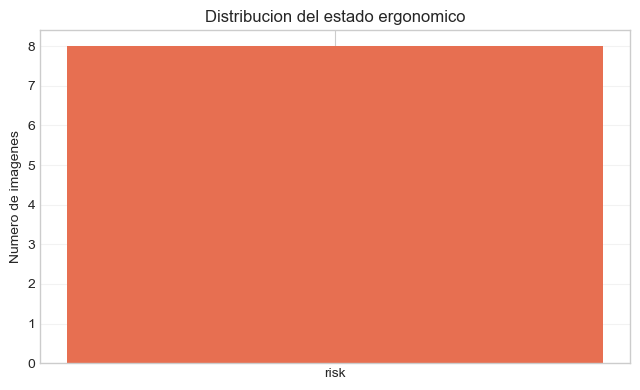

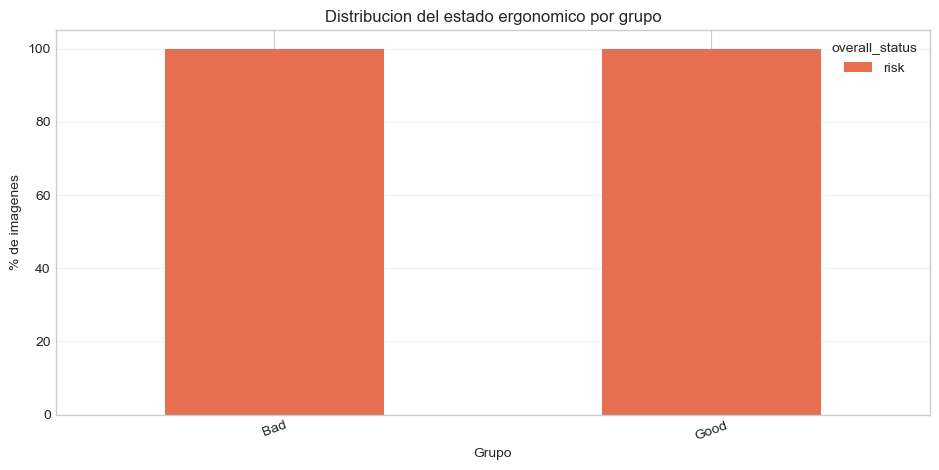

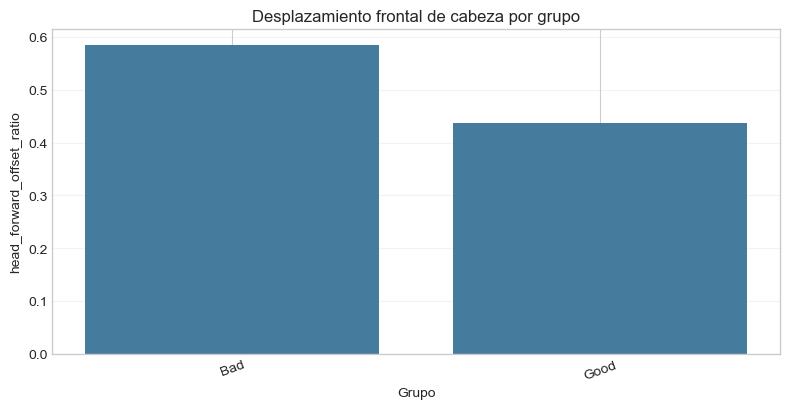

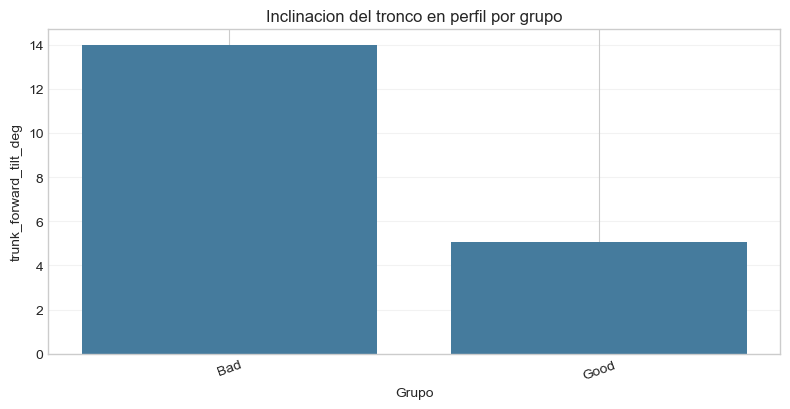

In [18]:
fig, ax = plot_status_distribution(demo_results_df)
plt.show()

fig, ax = plot_status_by_group(demo_results_df, normalize=True)
plt.show()

fig, ax = plot_metric_by_group(
    demo_results_df,
    metric="head_forward_offset_ratio",
    title="Desplazamiento frontal de cabeza por grupo",
)
plt.show()

fig, ax = plot_metric_by_group(
    demo_results_df,
    metric="trunk_forward_tilt_deg",
    title="Inclinacion del tronco en perfil por grupo",
)
plt.show()

## 5. Inspeccion visual

Esta revision visual es necesaria porque en lateral hay oclusiones normales.
El sistema elige automaticamente el lado corporal con mejor visibilidad.

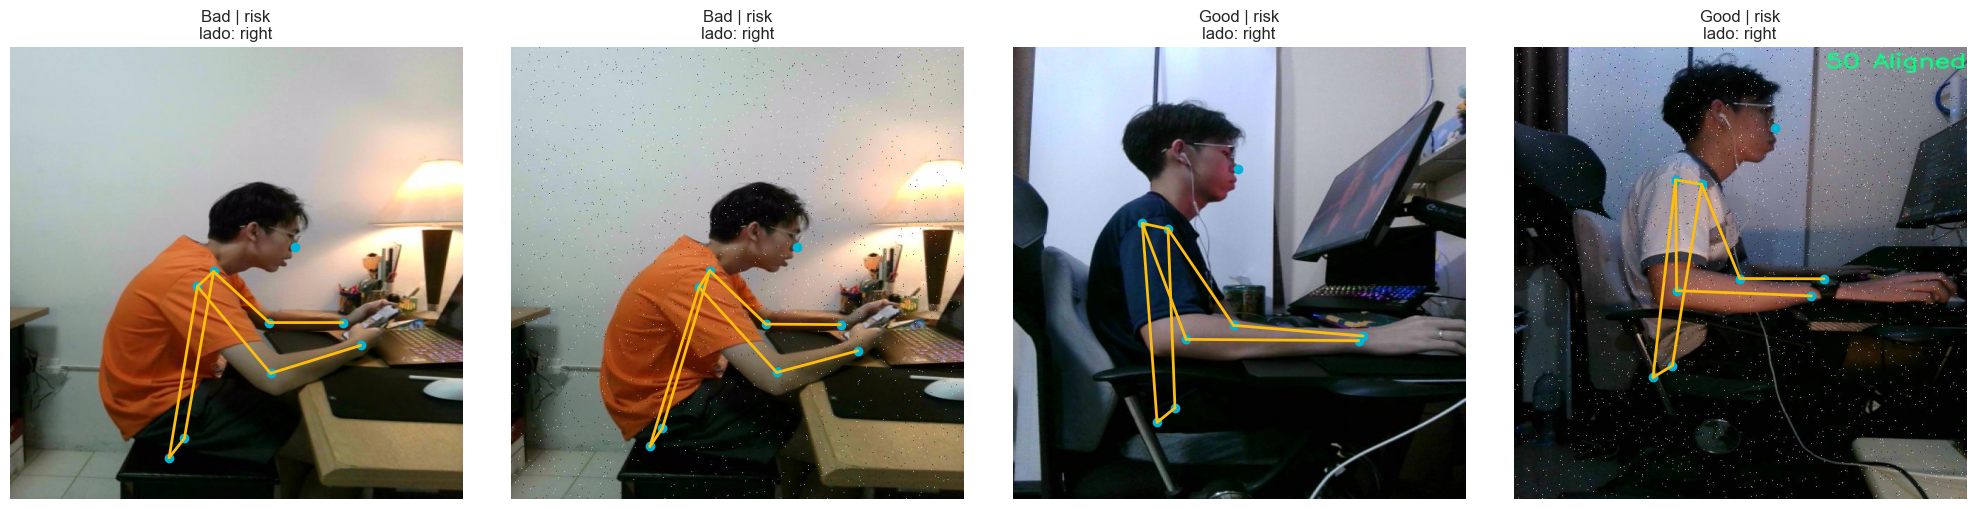

In [19]:
examples_df = (
    demo_results_df.sort_values(
        by=["group", "overall_status", "visible_landmarks_count"],
        ascending=[True, False, False],
    )
    .groupby("group", as_index=False)
    .head(2)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, len(examples_df), figsize=(5.2 * len(examples_df), 5.2))
if len(examples_df) == 1:
    axes = [axes]

pose_lookup = pose_df.set_index("image_path")

for ax, (_, example_row) in zip(axes, examples_df.iterrows(), strict=False):
    pose_row = pose_lookup.loc[example_row["image_path"]]
    draw_pose_overlay(example_row["image_path"], pose_row, ax=ax)
    ax.set_title(f"{example_row['group']} | {example_row['overall_status']}\nlado: {example_row['lateral_side']}")

plt.show()

## 6. Corrida larga lateral preparada

Esta seccion queda lista para procesar el dataset completo.
Por defecto esta desactivada para evitar lanzar una ejecucion larga accidental.

Para ejecutarla:
- pon `RUN_LATERAL_LONG_RUN = True`
- deja `LATERAL_MAX_IMAGES = None` para todo el dataset
- si se corta, vuelve a ejecutar con `RESUME_RUN = True`

In [20]:
RUN_LATERAL_LONG_RUN = True
LATERAL_EXECUTION_STRATEGY = "full_dataset"
LATERAL_MAX_IMAGES = int(os.environ["LATERAL_MAX_IMAGES"]) if os.getenv("LATERAL_MAX_IMAGES") else None
BALANCED_PER_GROUP = 300
CHECKPOINT_EVERY = 100
RESUME_RUN = True

RUN_LABEL = os.getenv("LATERAL_RUN_LABEL", f"{DATASET_KEY}_yolo_lateral_{LATERAL_EXECUTION_STRATEGY}")

records_df = select_execution_records(
    DATASET_KEY,
    strategy=LATERAL_EXECUTION_STRATEGY,
    per_group=BALANCED_PER_GROUP,
    max_images=LATERAL_MAX_IMAGES,
    splits=SPLITS,
    seed=SEED,
)

display(records_df.groupby(["split", "group"], dropna=False).size().rename("image_count").reset_index())
print(f"Imagenes programadas para corrida lateral: {len(records_df)}")
print(f"Run label: {RUN_LABEL}")
print(f"Ejecutar corrida larga: {RUN_LATERAL_LONG_RUN}")

,split,group,image_count
0,test,Bad,17
1,test,Good,10
2,train,Bad,366
3,train,Good,207
4,valid,Bad,37
5,valid,Good,18


Imagenes programadas para corrida lateral: 655
Run label: sitting_posture_4keypoint_yolo_lateral_full_dataset
Ejecutar corrida larga: True


In [21]:
if RUN_LATERAL_LONG_RUN:
    started_at = datetime.now()
    artifacts = run_incremental_lateral_yolo_pipeline(
        records_df,
        run_label=RUN_LABEL,
        yolo_config=yolo_config,
        visibility_threshold=VISIBILITY_THRESHOLD,
        checkpoint_every=CHECKPOINT_EVERY,
        resume=RESUME_RUN,
    )
    finished_at = datetime.now()

    display(
        pd.DataFrame(
            [
                {"item": "Run label", "value": RUN_LABEL},
                {"item": "Output dir", "value": str(artifacts.output_dir)},
                {"item": "Processed images", "value": artifacts.processed_images},
                {"item": "Duration", "value": str(finished_at - started_at)},
            ]
        )
    )
else:
    print("Corrida larga lateral omitida. Activa RUN_LATERAL_LONG_RUN=1 para ejecutarla.")

Long run lateral YOLO: 100%|██████████| 655/655 [00:08<00:00, 75.46it/s]


,item,value
0,Run label,sitting_posture_4keypoint_yolo_lateral_full_da...
1,Output dir,/home/veleiro/OneDrive/Clase/3º de IA/2º Cuatr...
2,Processed images,655
3,Duration,0:00:08.765721


## 7. Lectura de artefactos laterales

Cuando ejecutes la corrida grande, esta seccion permite leer los CSV y revisar resultados sin repetir inferencia.

,overall_status,image_count,share_pct
0,risk,643,98.168
1,insufficient_data,12,1.832


,group,overall_status,image_count,share_pct
0,Bad,insufficient_data,3,0.714
1,Bad,risk,417,99.286
2,Good,insufficient_data,9,3.830
3,Good,risk,226,96.170


,group,head_forward_offset_ratio,neck_forward_tilt_deg,trunk_forward_tilt_deg,shoulder_hip_offset_ratio,lateral_elbow_angle_deg
0,Bad,0.549,69.307,12.822,0.218,96.726
1,Good,0.434,52.554,6.168,0.107,108.786


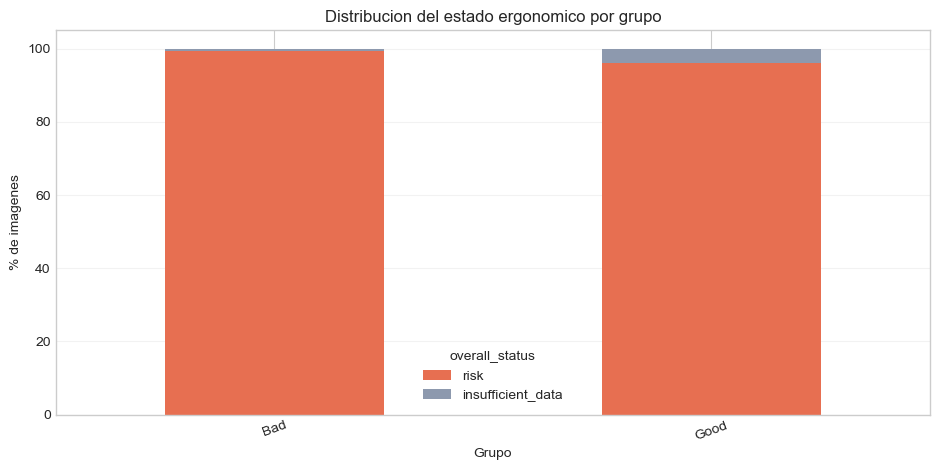

In [22]:
RUN_OUTPUT_DIR = ERGONOMICS_RESULTS_DIR / RUN_LABEL
analysis_path = RUN_OUTPUT_DIR / "ergonomic_analysis.csv"

if analysis_path.exists():
    long_analysis_df = pd.read_csv(analysis_path)
    status_summary_df = build_status_summary(long_analysis_df)
    group_status_summary_df = build_group_status_summary(long_analysis_df)
    metric_summary_df = build_metric_summary_by_group(
        long_analysis_df,
        metrics=[
            "head_forward_offset_ratio",
            "neck_forward_tilt_deg",
            "trunk_forward_tilt_deg",
            "shoulder_hip_offset_ratio",
            "lateral_elbow_angle_deg",
        ],
    )

    display(status_summary_df)
    display(group_status_summary_df)
    display(metric_summary_df)

    fig, ax = plot_status_by_group(long_analysis_df, normalize=True)
    plt.show()
else:
    print(f"Todavia no hay artefactos en {RUN_OUTPUT_DIR}")